In [71]:
# Basic imports
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Visuallization style 
plt.style.use('seaborn-v0_8')

# Check current working directory
print(os.getcwd())
print(os.listdir('..'))

c:\Users\VRAJPBH\OneDrive - Pearson\Documents\GitHub\Loan-Default-Risk\notebooks
['.git', '.gitignore', 'data', 'LICENSE', 'notebooks', 'README.md', 'requirements.txt']


In [72]:
# Load dataset
df = pd.read_csv('C:\\Users\\VRAJPBH\\OneDrive - Pearson\\Documents\\GitHub\\Loan-Default-Risk\\data\\credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [73]:
# Dataset overview

print("Shape:", df.shape)
df.info()

Shape: (32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [74]:
# Display column names
df.columns

# Define target variable 
# loan_status: 1 - Default, 0 - Paid Off
df['loan_status'].value_counts(normalize=True) 

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

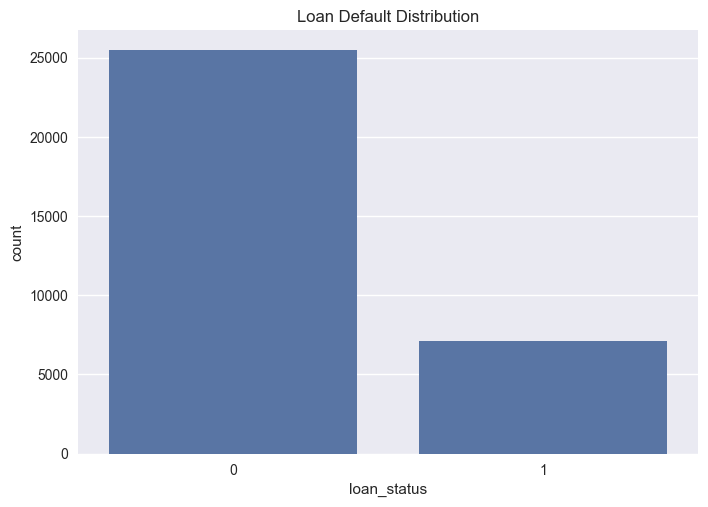

In [75]:
# Target distribution visualization
sns.countplot(x='loan_status', data=df)
plt.title('Loan Default Distribution')
plt.show()

### Target Variable Insight

The dataset shows class imbalance, with fewer loan defaults compared to non-defaults.
Therefore, evaluation metrics such as recall, F1-score, and ROC-AUC are more appropriate
than accuracy for assessing model performance.


In [76]:
# Missing values analysis
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [77]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [78]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

In [79]:
# Split features and target variable
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']


In [80]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [81]:
# Baseline model with Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5095
           1       0.73      0.46      0.56      1422

    accuracy                           0.85      6517
   macro avg       0.80      0.71      0.73      6517
weighted avg       0.83      0.85      0.83      6517

ROC AUC Score: 0.8462067413931367


C:\Users\VRAJPBH\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Baseline Model Insight

Logistic Regression provides a strong baseline for loan default prediction.
However, due to non-linear relationships in financial data, more advanced models
may improve performance.


In [82]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [83]:
# Make predictions

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

In [84]:
# Evaluate random forest model

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))

# Confusion Matrix
confusion_matrix(y_test, y_pred_rf)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517

ROC AUC Score: 0.9320091951928824


array([[5060,   35],
       [ 406, 1016]])

### Model Comparison

Random Forest outperformed Logistic Regression by capturing non-linear relationships
between borrower attributes and default risk. It achieved a higher ROC-AUC and
improved recall for default cases, making it more suitable for financial risk prediction.


In [85]:
# Feature importance

feature_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns).sort_values(ascending=False)

feature_importances.head(10)


loan_percent_income            0.201224
person_income                  0.163405
loan_int_rate                  0.142125
loan_amnt                      0.082900
loan_grade_D                   0.057966
person_home_ownership_RENT     0.056126
person_emp_length              0.054322
person_age                     0.051200
cb_person_cred_hist_length     0.040940
cb_person_default_on_file_Y    0.019354
dtype: float64

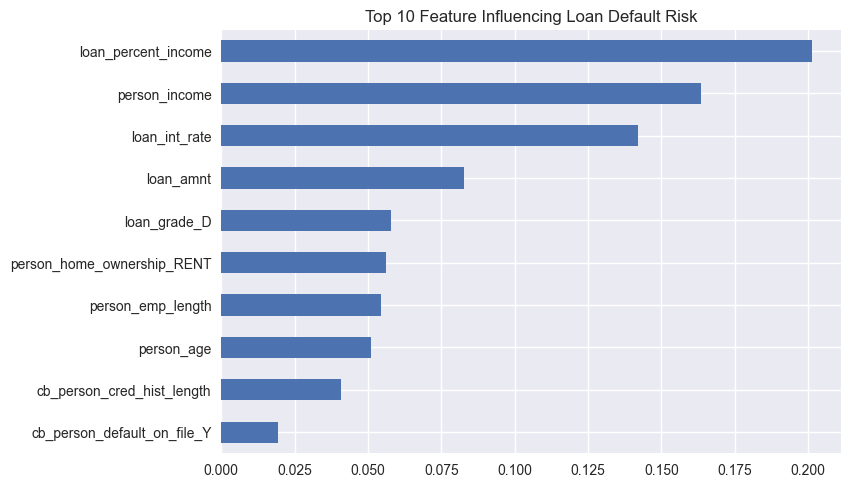

In [86]:
# plot top feature 

feature_importances.head(10).plot(
    kind='barh',
    title='Top 10 Feature Influencing Loan Default Risk'
)

plt.gca().invert_yaxis()
plt.show()

### Key Risk Drivers

The most influential factors in predicting loan default include loan interest rate,
loan amount, borrower income, employment length, and credit history indicators.
These features can help financial institutions assess borrower risk more effectively.
